<a href="https://colab.research.google.com/github/Kush0319/Final-Project/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [8]:
df = pd.read_csv("/content/AAPL.csv")

print(df.head())
print(df.info())
print(df.describe())

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1  1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
2  1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000
3  1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400
4  1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   object 
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 542.0+ KB
None
         

In [9]:
print(df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [13]:
df["Date"] = pd.to_datetime(df["Date"])

In [12]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print(df.columns)

Rows : 9909
Columns : 7
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [14]:
print("Highest Close Price")

print(df["Close"].max())

Highest Close Price
327.20001220703125


In [15]:
print(df["Close"].min())

0.1964285671710968


In [16]:
print(df["Close"].mean())

32.618030149898296


In [17]:
print(df["Volume"].max())

1855410200


In [18]:
print(df.corr(numeric_only=True))

               Open      High       Low     Close  Adj Close    Volume
Open       1.000000  0.999935  0.999931  0.999878   0.998933 -0.133347
High       0.999935  1.000000  0.999887  0.999929   0.999041 -0.132296
Low        0.999931  0.999887  1.000000  0.999931   0.998992 -0.135045
Close      0.999878  0.999929  0.999931  1.000000   0.999098 -0.133697
Adj Close  0.998933  0.999041  0.998992  0.999098   1.000000 -0.142612
Volume    -0.133347 -0.132296 -0.135045 -0.133697  -0.142612  1.000000


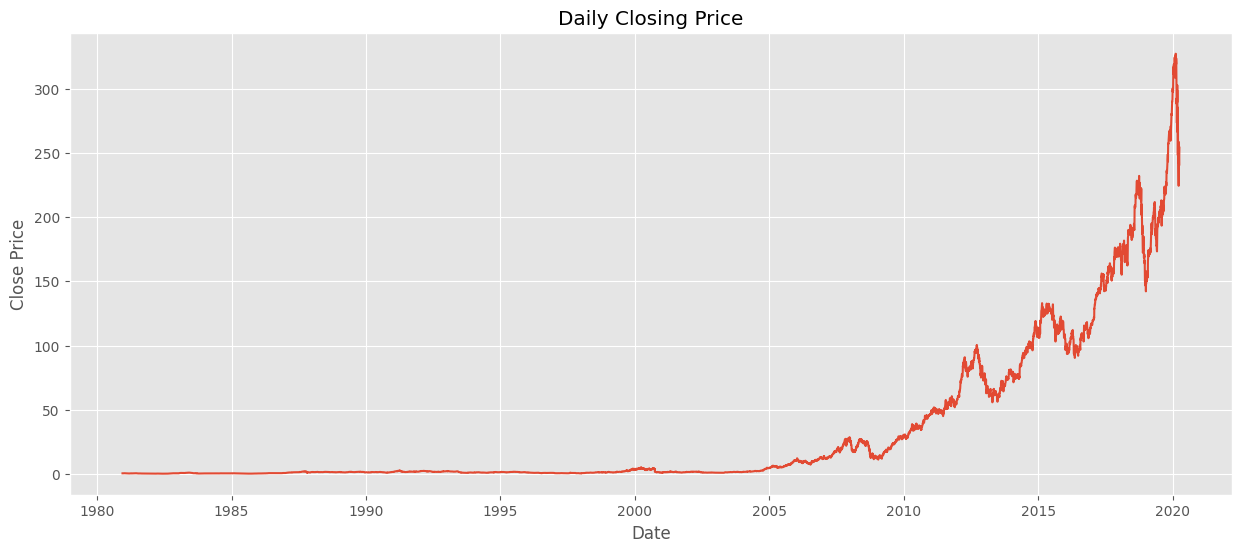

In [19]:
plt.figure(figsize=(15,6))

plt.plot(df["Date"],df["Close"])

plt.title("Daily Closing Price")

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.show()

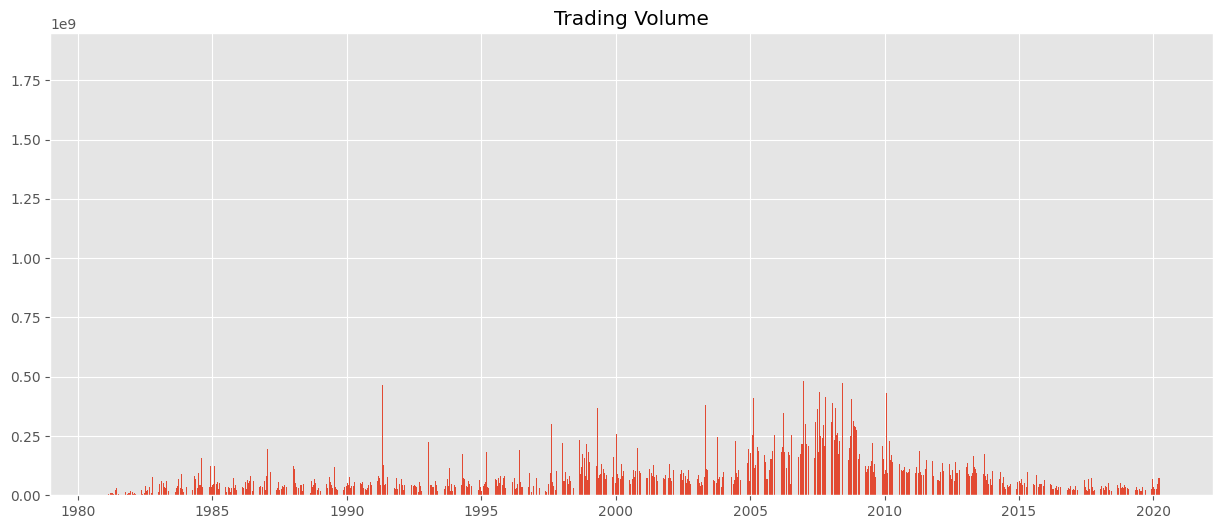

In [20]:
plt.figure(figsize=(15,6))

plt.bar(df["Date"],df["Volume"])

plt.title("Trading Volume")

plt.show()

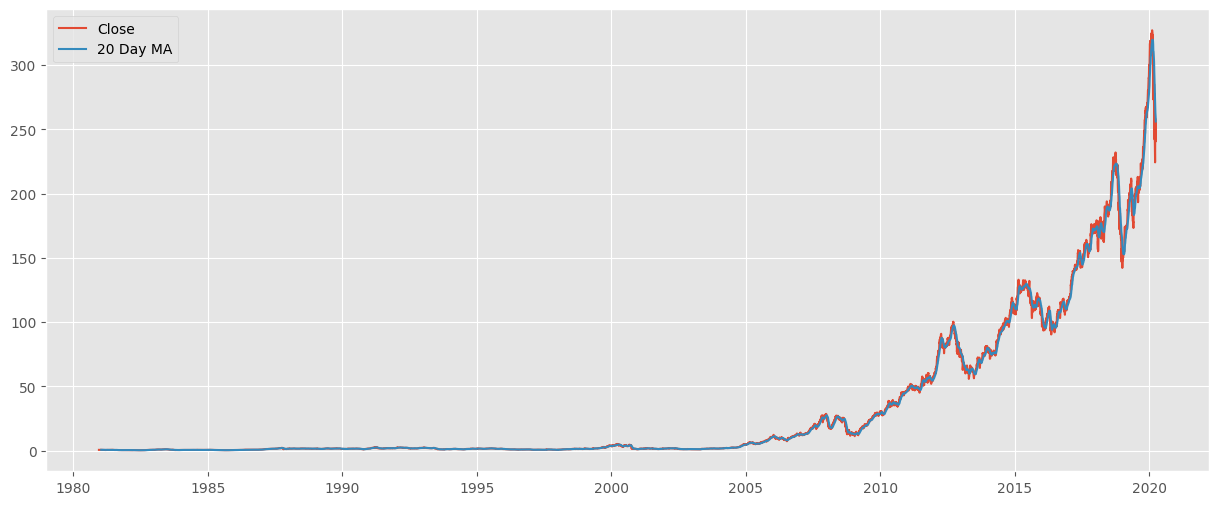

In [21]:
df["MA20"]=df["Close"].rolling(20).mean()

plt.figure(figsize=(15,6))

plt.plot(df["Date"],df["Close"],label="Close")

plt.plot(df["Date"],df["MA20"],label="20 Day MA")

plt.legend()

plt.show()

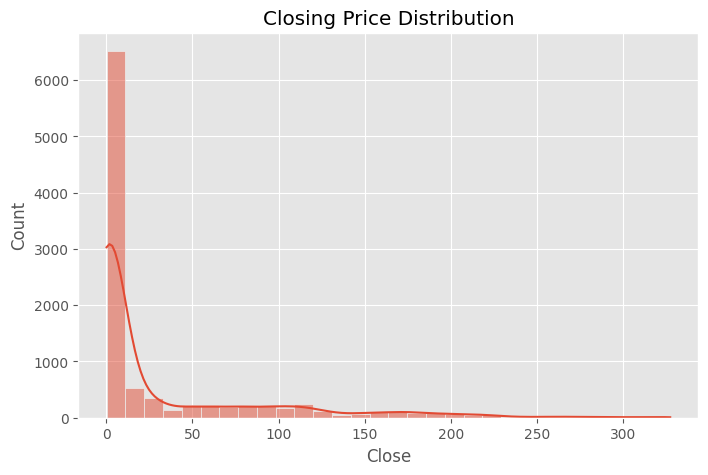

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["Close"],bins=30,kde=True)

plt.title("Closing Price Distribution")

plt.show()

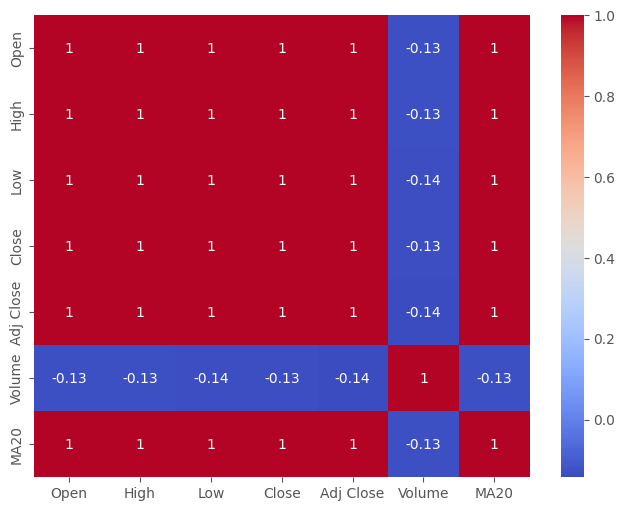

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

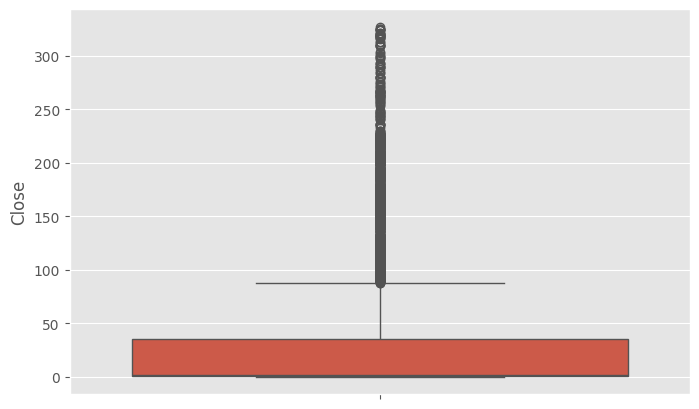

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Close"])

plt.show()

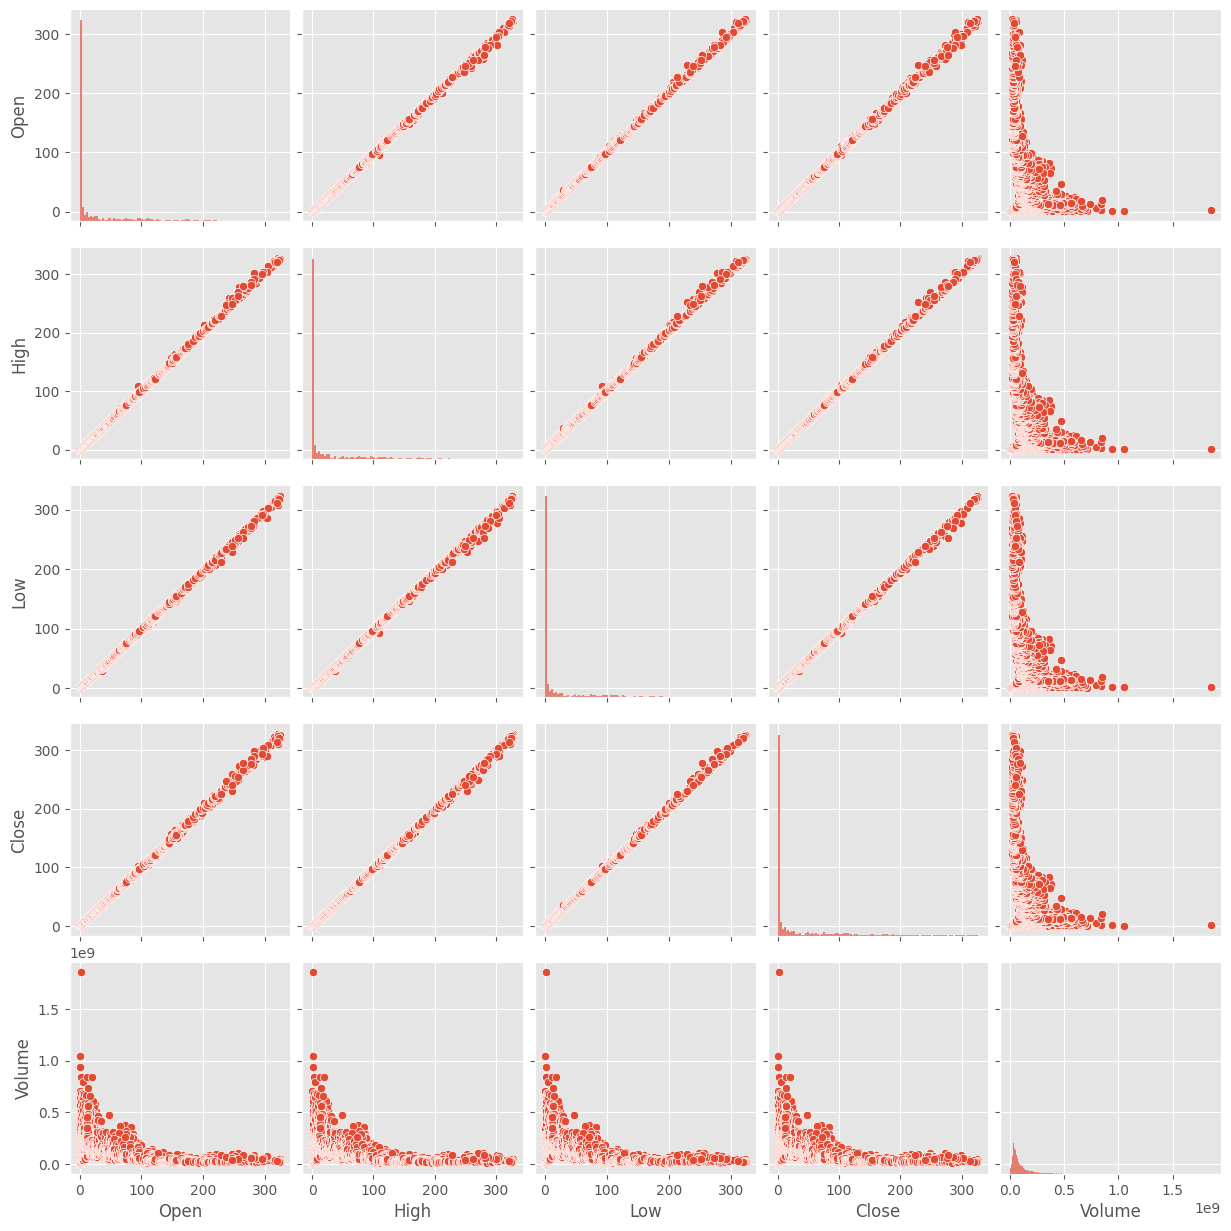

In [25]:
sns.pairplot(df[["Open","High","Low","Close","Volume"]])

plt.show()

In [26]:
df["Daily Return"] = df["Close"].pct_change()

print(df.head())

        Date      Open      High       Low     Close  Adj Close     Volume  \
0 1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400   
1 1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200   
2 1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000   
3 1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400   
4 1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400   

   MA20  Daily Return  
0   NaN           NaN  
1   NaN     -0.052174  
2   NaN     -0.073394  
3   NaN      0.024752  
4   NaN      0.028986  


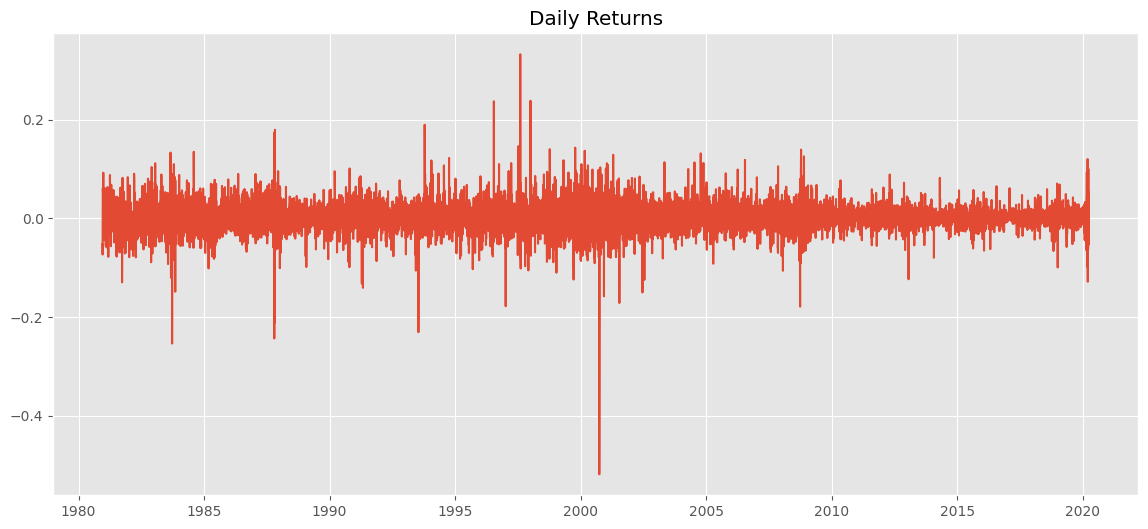

In [27]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"],df["Daily Return"])

plt.title("Daily Returns")

plt.show()

In [28]:
volatility = df["Daily Return"].std()

print("Volatility :",volatility)

Volatility : 0.028737743712088686


In [29]:
top = df.nlargest(10,"Close")

print(top[["Date","Close"]])

           Date       Close
9874 2020-02-12  327.200012
9870 2020-02-06  325.209991
9876 2020-02-14  324.950012
9875 2020-02-13  324.869995
9864 2020-01-29  324.339996
9865 2020-01-30  323.869995
9878 2020-02-19  323.619995
9872 2020-02-10  321.549988
9869 2020-02-05  321.450012
9879 2020-02-20  320.299988


In [30]:
df.to_csv("/content/cleaned_stock_data.csv",index=False)